# Laboratory 01 · From G–X curves to equilibrium phase fractions
**Thermodynamics and Kinetics of Materials · NPTEL course companion**  
Level: undergraduate materials science · Suggested time: 45–60 minutes

How can two phases with different compositions have the same chemical potentials? Why is the intersection of two G–X curves usually **not** the equilibrium answer?

You will draw tangents, read chemical potentials from intercepts, compute a common tangent, and use conservation to obtain phase amounts. Predict each result before running its cell. Submit your plots, calculations and short explanations for the five exercises; the instructor section at the end provides worked checks.

**Prerequisites:** mole fraction, molar Gibbs energy, derivatives and binary phase equilibria. Only basic Python is needed. This is an original, fictional A–B model, not an assessed alloy database or a prediction for a real material.

## 1. Setup and run
Use Python 3.10 or newer and JupyterLab. In a terminal, create an environment:

```bash
python -m venv .venv
# Linux/macOS:
source .venv/bin/activate
# Windows PowerShell instead:
# .venv\Scripts\Activate.ps1
python -m pip install numpy scipy matplotlib jupyterlab
python -m jupyter lab
```
Open this notebook and choose **Kernel → Restart Kernel and Run All Cells**. Alternatively, upload the notebook to Google Colab and run it; install missing packages there with `%pip install numpy scipy matplotlib`. No database, API key or internet connection is needed after installation. Saved outputs let you inspect the reference run without executing anything.

The parameter cell in §2 is the place to experiment. After a change, rerun from that cell downward. The instructor section deliberately restores its own baseline parameters so its checks remain reproducible.

In [1]:
import sys
import numpy as np
import scipy
from scipy.optimize import brentq, linprog
from scipy.special import xlogy, expit
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | "
      f"SciPy {scipy.__version__} | Matplotlib {matplotlib.__version__}")

Python 3.12.14 | NumPy 2.3.5 | SciPy 1.17.0 | Matplotlib 3.10.8


## 2. A self-contained two-phase binary
At fixed temperature $T$ and pressure, let $x=n_B/(n_A+n_B)$ and $g=G/(n_A+n_B)$, in J mol$^{-1}$. There are two substitutional, ideal-solution phases, $\alpha$ and $\beta$, with the same composition variable and consistent pure-component references:

| Phase | $g_A^0$ (J mol$^{-1}$) | $g_B^0$ (J mol$^{-1}$) |
|---|---:|---:|
| $\alpha$ | 0 | 12000 |
| $\beta$ | 8000 | 0 |

$$g^\phi(x,T)=(1-x)g_A^{0,\phi}+xg_B^{0,\phi}
 +RT[(1-x)\ln(1-x)+x\ln x].$$

The reference energies are intentionally constant with temperature for this small teaching model. A prefers $\alpha$, B prefers $\beta$; configurational entropy favors mixing. We neglect interfaces, elasticity, finite-size effects, kinetics and all other phases. Phase fractions below are **mole fractions of material in each phase**, not mass or volume fractions.

Use $0\ln0=0$ for energy at pure endpoints. Chemical potentials have logarithmic limits there, so tangents are evaluated only for $0<x<1$. Each branch is convex: $g''=RT/[x(1-x)]>0$. Two-phase equilibrium here arises from *two different branches*, not a spinodal instability of one branch.

In [2]:
# Student controls: J/mol, K, and dimensionless mole fractions.
R = 8.314462618
T = 800.0
z = 0.40                 # overall B mole fraction
x_probe = 0.35           # composition for the single-phase tangent
refs = {"alpha": (0.0, 12000.0), "beta": (8000.0, 0.0)}


def g(x, T, phase):
    x = np.asarray(x, dtype=float)
    if T <= 0 or np.any((x < 0) | (x > 1)):
        raise ValueError("Require T > 0 and 0 <= x <= 1.")
    a, b = refs[phase]
    return (1-x)*a + x*b + R*T*(xlogy(x, x) + xlogy(1-x, 1-x))


def dg(x, T, phase):
    x = np.asarray(x, dtype=float)
    if T <= 0 or np.any((x <= 0) | (x >= 1)):
        raise ValueError("Tangents require T > 0 and 0 < x < 1.")
    a, b = refs[phase]
    return b-a + R*T*np.log(x/(1-x))


def mu(x, T, phase):
    slope = dg(x, T, phase)
    return g(x, T, phase)-x*slope, g(x, T, phase)+(1-x)*slope

x = np.linspace(0, 1, 1001)
colors = {"alpha": "#1665a7", "beta": "#bb4b25"}

## 3. The tangent tells us both chemical potentials
At fixed $T,P$, $G=ng(x)$ with $n=n_A+n_B$. Differentiating with respect to each component amount gives
$$\mu_A=\left(\frac{\partial G}{\partial n_A}\right)_{T,P,n_B}=g-xg',\qquad
\mu_B=\left(\frac{\partial G}{\partial n_B}\right)_{T,P,n_A}=g+(1-x)g'.$$
Thus $g'=\mu_B-\mu_A$, not either individual chemical potential. The tangent through $x_0$ is
$$\ell(x)=g(x_0)+g'(x_0)(x-x_0)=(1-x)\mu_A(x_0)+x\mu_B(x_0).$$
Its extrapolated values at $x=0$ and $x=1$ give $\mu_A$ and $\mu_B$. These are **not** generally the pure-component energies.

**Expected plot:** one convex $\alpha$ curve and its tangent, touching at $x=0.35$. The left and right tangent intercepts are explicitly marked. Moving $x_0$ changes both intercepts.

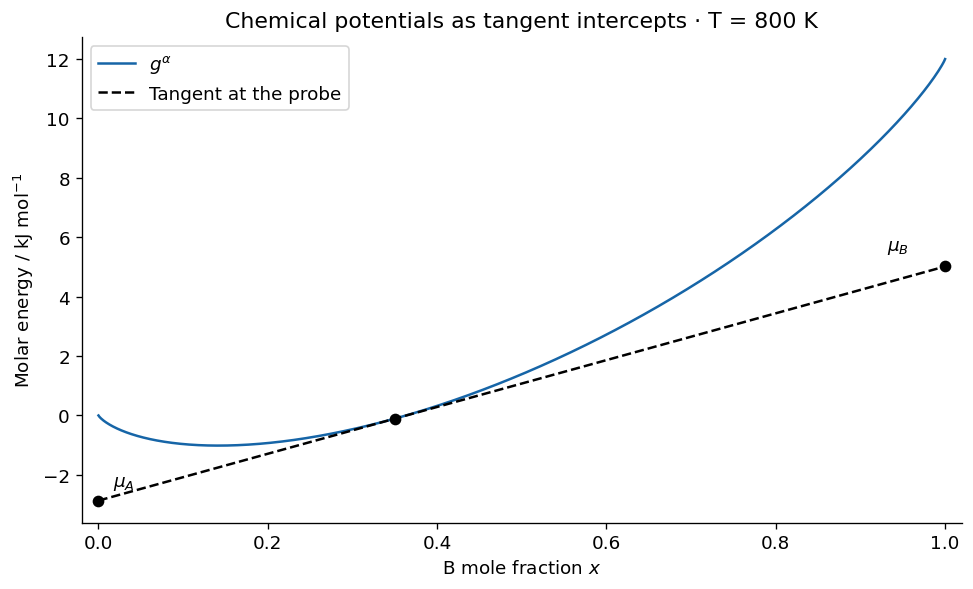

mu_A = -2865.383, mu_B = 5017.035, slope = 7882.417 J/mol


In [3]:
ma, mb = mu(x_probe, T, "alpha")
fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
ax.plot(x, g(x, T, "alpha")/1000, color=colors["alpha"], label=r"$g^\alpha$")
ax.plot(x, ((1-x)*ma+x*mb)/1000, "k--", label="Tangent at the probe")
ax.scatter([0, x_probe, 1], [ma/1000, g(x_probe,T,"alpha")/1000, mb/1000], color="black", zorder=4)
ax.annotate(r"$\mu_A$", (0, ma/1000), xytext=(9, 9), textcoords="offset points")
ax.annotate(r"$\mu_B$", (1, mb/1000), xytext=(-35, 10), textcoords="offset points")
ax.set(xlim=(-0.02,1.02), xlabel=r"B mole fraction $x$", ylabel="Molar energy / kJ mol$^{-1}$",
       title=f"Chemical potentials as tangent intercepts · T = {T:g} K")
ax.legend(loc="upper left")
plt.show()
print(f"mu_A = {ma:.3f}, mu_B = {mb:.3f}, slope = {mb-ma:.3f} J/mol")

## 4. A common tangent enforces equilibrium
For coexisting compositions $x_\alpha,x_\beta$,
$$\mu_A^\alpha(x_\alpha)=\mu_A^\beta(x_\beta),\qquad
\mu_B^\alpha(x_\alpha)=\mu_B^\beta(x_\beta).$$
Equivalently, the tangents have the **same slope and intercept**:
$$g_\alpha'(x_\alpha)=g_\beta'(x_\beta)=m,\quad
 g_\alpha(x_\alpha)-mx_\alpha=g_\beta(x_\beta)-mx_\beta=b.$$
Parallel tangents alone are insufficient. Also require a supporting line below all allowed energy branches; otherwise a stationary construction need not be globally stable.

For a trial slope $m$, our ideal-solution formula can be inverted:
$$x_\phi(m)=\frac{1}{1+\exp[(g_B^{0,\phi}-g_A^{0,\phi}-m)/(RT)]}.$$
We vary $m$ until the two tangent intercepts coincide. `brentq` is a bracketed scalar root solver. `expit` and `logaddexp` evaluate the expressions without unnecessary exponential overflow. This inversion is specific to the ideal model, not a universal CALPHAD solver.

In [4]:
def coexistence(T):
    # Guard the teaching range against endpoint roundoff at extreme T.
    if not 200 <= T <= 3000:
        raise ValueError("Use 200 <= T <= 3000 K for this laboratory.")

    def composition(m, phase):
        a, b = refs[phase]
        return expit((m-(b-a))/(R*T))

    def intercept(m, phase):
        a, b = refs[phase]
        return a-R*T*np.logaddexp(0, (m-(b-a))/(R*T))

    def residual(m):
        return intercept(m, "alpha")-intercept(m, "beta")

    m = brentq(residual, -200000.0, 200000.0, xtol=1e-9)
    xa, xb = composition(m, "alpha"), composition(m, "beta")
    if not 0 < xa < xb < 1:
        raise ValueError("This lab assumes alpha is A-rich and beta is B-rich.")
    return xa, xb, m, intercept(m, "alpha")

xa, xb, slope, intercept = coexistence(T)
print(f"x_alpha = {xa:.6f}; x_beta = {xb:.6f}")
print(f"Common mu_A = {intercept:.3f}; mu_B = {intercept+slope:.3f} J/mol")
print("                    mu_A          mu_B (J/mol)")
for phase, xp in [("alpha", xa), ("beta", xb)]:
    aa, bb = mu(xp, T, phase)
    print(f"{phase:8s} {aa:15.6f} {bb:15.6f}")

x_alpha = 0.121167; x_beta = 0.736021
Common mu_A = -859.122; mu_B = -2038.687 J/mol
                    mu_A          mu_B (J/mol)
alpha        -859.122196    -2038.687054
beta         -859.122196    -2038.687054


## 5. Equilibrium amounts: the lever rule
Let $z$ be the **overall** B mole fraction, with $f_\alpha+f_\beta=1$. Conservation requires
$$z=f_\alpha x_\alpha+f_\beta x_\beta.$$
For $x_\alpha<z<x_\beta$,
$$f_\beta=\frac{z-x_\alpha}{x_\beta-x_\alpha},\qquad
f_\alpha=\frac{x_\beta-z}{x_\beta-x_\alpha},\quad
g_{\rm eq}(z)=f_\alpha g_\alpha(x_\alpha)+f_\beta g_\beta(x_\beta).$$
Outside this interval the stable state is a single phase at composition $z$; do **not** extrapolate the lever rule to negative fractions. At a boundary the amount of the incipient phase is zero. The common tangent extended outside the interval is not an attainable mixture of these two endpoint compositions.

**Expected plot:** two convex curves, a dashed supporting line and a thick lower equilibrium envelope. Inside the tie line the envelope is straight. The marked energy saving at $z$ compares equilibrium to the *lower homogeneous branch at the same overall composition*. It is an energy per mole, not a kinetic rate or activation barrier.

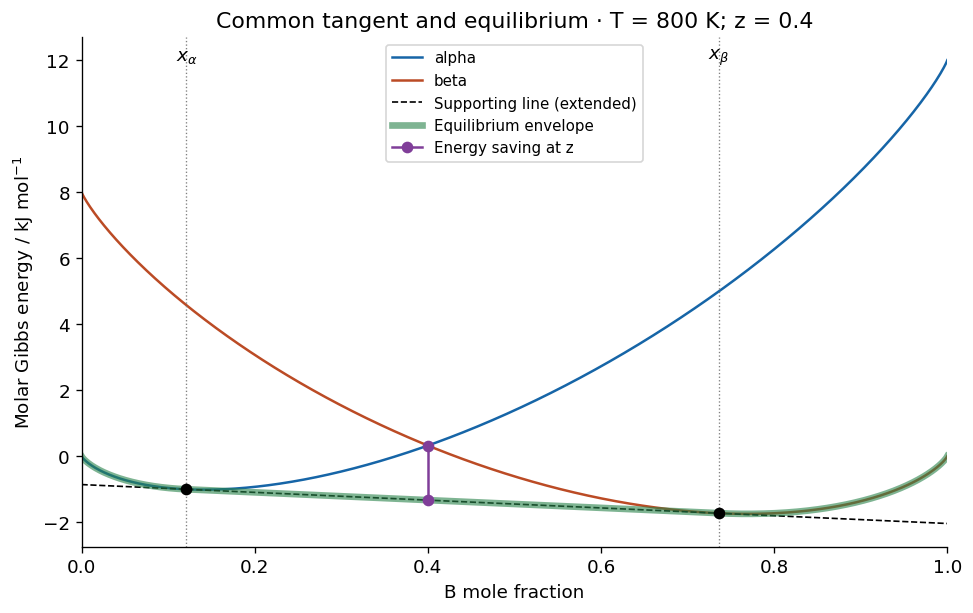

f_alpha = 0.546505; f_beta = 0.453495
g_eq = -1330.948; homogeneous excess = 1654.364 J/mol
Reconstructed z = 0.400000000000


In [5]:
def equilibrium(z, T):
    z = np.asarray(z, dtype=float)
    if np.any((z < 0) | (z > 1)):
        raise ValueError("Require 0 <= z <= 1.")
    xa, xb, m, b = coexistence(T)
    fb = np.clip((z-xa)/(xb-xa), 0, 1)
    fa = 1-fb
    geq = np.where(z <= xa, g(z,T,"alpha"),
           np.where(z >= xb, g(z,T,"beta"), b+m*z))
    return fa, fb, geq

fa, fb, geq = equilibrium(z,T)
ghom = min(g(z,T,"alpha"), g(z,T,"beta"))
fig, ax = plt.subplots(figsize=(8,5), layout="constrained")
for phase in refs:
    ax.plot(x, g(x,T,phase)/1000, color=colors[phase], label=phase)
ax.plot(x, (intercept+slope*x)/1000, "k--", lw=1, label="Supporting line (extended)")
ax.plot(x, equilibrium(x,T)[2]/1000, color="#29834a", lw=4, alpha=.6, label="Equilibrium envelope")
ax.scatter([xa,xb], [g(xa,T,"alpha")/1000,g(xb,T,"beta")/1000], color="black", zorder=5)
for xp, lab in [(xa,r"$x_\alpha$"),(xb,r"$x_\beta$")]:
    ax.axvline(xp, color="gray", ls=":", lw=.8)
    ax.text(xp, .98, lab, transform=ax.get_xaxis_transform(), ha="center", va="top")
ax.plot([z,z], [float(geq)/1000,ghom/1000], "o-", color="#803e99", label="Energy saving at z")
ax.set(xlim=(0,1), xlabel="B mole fraction", ylabel="Molar Gibbs energy / kJ mol$^{-1}$",
       title=f"Common tangent and equilibrium · T = {T:g} K; z = {z:g}")
ax.legend(loc="upper center", fontsize=9)
plt.show()
print(f"f_alpha = {fa:.6f}; f_beta = {fb:.6f}")
print(f"g_eq = {geq:.3f}; homogeneous excess = {ghom-geq:.3f} J/mol")
if xa <= z <= xb:
    print(f"Reconstructed z = {fa*xa+fb*xb:.12f}")
else:
    print("Single phase: its composition equals z.")

**Expected plots below:** phase fractions vary linearly only inside the two-phase interval; equilibrium chemical potentials remain constant across that interval even while $z$ and phase amounts change. Outside it, chemical potentials follow the appropriate homogeneous phase. Endpoints are omitted from the chemical-potential panel because one component is infinitely dilute.

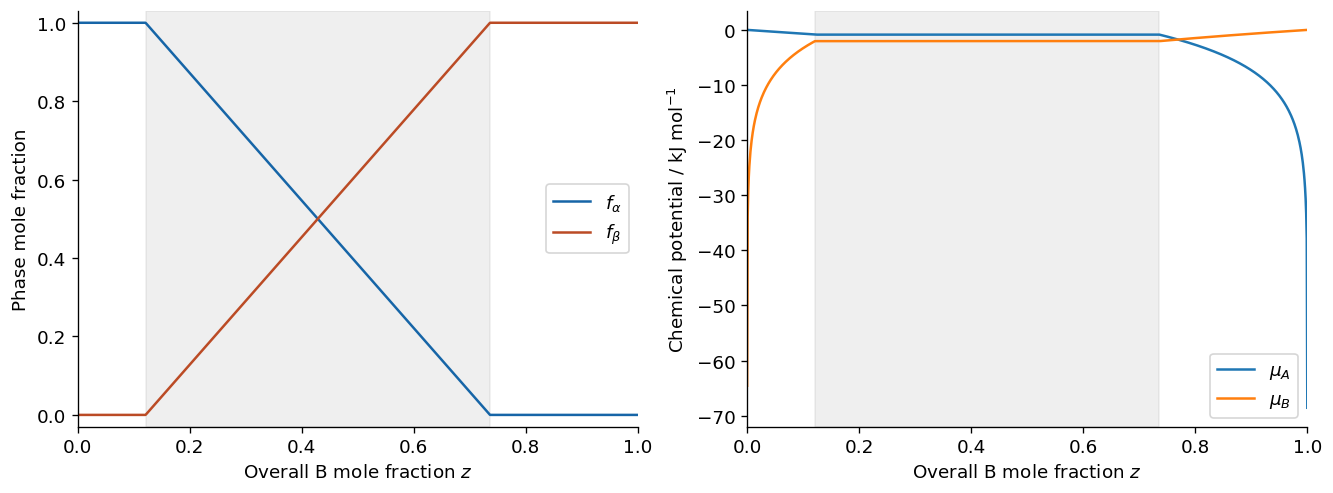

In [6]:
zz = np.linspace(1e-5,1-1e-5,1001)
fa_grid, fb_grid, _ = equilibrium(zz,T)
ma_a, mb_a = mu(zz,T,"alpha")
ma_b, mb_b = mu(zz,T,"beta")
ma_eq = np.where(zz<xa, ma_a, np.where(zz>xb, ma_b, intercept))
mb_eq = np.where(zz<xa, mb_a, np.where(zz>xb, mb_b, intercept+slope))
fig, axes = plt.subplots(1,2,figsize=(11,4),layout="constrained")
axes[0].plot(zz,fa_grid,label=r"$f_\alpha$",color=colors["alpha"])
axes[0].plot(zz,fb_grid,label=r"$f_\beta$",color=colors["beta"])
axes[0].set(ylabel="Phase mole fraction",ylim=(-.03,1.03))
axes[1].plot(zz,ma_eq/1000,label=r"$\mu_A$")
axes[1].plot(zz,mb_eq/1000,label=r"$\mu_B$")
axes[1].set(ylabel="Chemical potential / kJ mol$^{-1}$")
for ax in axes:
    ax.axvspan(xa,xb,color="gray",alpha=.12)
    ax.set(xlabel=r"Overall B mole fraction $z$",xlim=(0,1))
    ax.legend()
plt.show()

## 6. Short student exercises
Write a prediction first, then use the code. Keep units and distinguish $z$ from $x_\alpha,x_\beta$.

1. **Intercepts (2 marks).** At $T=800$ K, $x_0=0.35$ on $\alpha$, calculate both chemical potentials and the slope. Explain why the slope alone cannot give both potentials.
2. **Equilibrium amounts (3 marks).** At 800 K, find $x_\alpha,x_\beta$ and the fractions for $z=0.20,0.40,0.70$. Which quantities change with $z$? Verify the B balance for one case. Then classify $z=0.05,0.90$.
3. **The crossing trap (2 marks).** Find where $g_\alpha(x)=g_\beta(x)$. At that composition, are the slopes equal? Compare the homogeneous energy with the equilibrium energy. Explain why equal $g$ at the same composition is insufficient.
4. **Temperature experiment (2 marks).** Repeat the common-tangent calculation at 600, 800 and 1200 K, holding $z=0.40$. Tabulate both phase compositions and fractions. Does the tie-line interval widen or narrow? Explain using mixing entropy, within this model's assumptions.
5. **Reference-energy challenge (1 mark).** Add the same affine term $c+dx$ to *both* branches, using $c=1500$, $d=-2000$ J/mol. Predict changes in compositions, fractions, common-tangent slope and both chemical potentials. Explain why relative phase energies, rather than a common reference choice, determine equilibrium.

**Submission:** two annotated plots (common tangent and phase fractions), the temperature table and brief answers. The remaining section is an answer key; attempt the exercises before reading it.

In [7]:
# Student workspace: add your calculations and explanations here.
# Example starting point:
for z_try in [0.20, 0.40, 0.70]:
    pass  # calculate and print equilibrium(z_try, 800.0)

## 7. Instructor solution and numerical checks
This section is deliberately included for self-study. It restores the original model. Code cells are tagged `instructor-solution` for removal when preparing an assessed version; Markdown answers would also need removal.

An independent analytic result follows directly from the ideal-solution chemical potentials. Define
$$K_A=\exp[(g_A^{0,\alpha}-g_A^{0,\beta})/(RT)],\quad
K_B=\exp[(g_B^{0,\alpha}-g_B^{0,\beta})/(RT)].$$
Equality of potentials gives $1-x_\beta=K_A(1-x_\alpha)$ and $x_\beta=K_Bx_\alpha$, hence
$$x_\alpha=\frac{1-K_A}{K_B-K_A},\qquad x_\beta=K_Bx_\alpha.$$
This provides a check independent of the slope-root construction.

In [8]:
# Restore baseline independently of student experiments.
refs = {"alpha": (0.0, 12000.0), "beta": (8000.0, 0.0)}
T0, z0 = 800.0, 0.40
xa0, xb0, m0, b0 = coexistence(T0)
print("1. Probe mu_A, mu_B:", np.round(mu(.35,T0,"alpha"),3), "J/mol")
print("   Probe slope:", round(float(dg(.35,T0,"alpha")),3), "J/mol")
print("2. Lever-rule results at 800 K")
for zi in [.05,.20,.40,.70,.90]:
    fai,fbi,gi = equilibrium(zi,T0)
    print(f"   z={zi:.2f}: f_alpha={fai:.6f}, f_beta={fbi:.6f}")
x_cross = 8000/(12000+8000)
excess = min(g(x_cross,T0,"alpha"),g(x_cross,T0,"beta"))-equilibrium(x_cross,T0)[2]
print(f"3. Crossing x={x_cross:.3f}; slope difference = "
      f"{dg(x_cross,T0,'alpha')-dg(x_cross,T0,'beta'):.1f} J/mol")
print(f"   Homogeneous excess over equilibrium = {excess:.3f} J/mol")
print("4. Temperature table (z=0.40)")
print("   T/K      x_alpha   x_beta    f_alpha   f_beta")
for ti in [600.,800.,1200.]:
    ai,bi,_,_ = coexistence(ti)
    fi,fj,_ = equilibrium(.4,ti)
    print(f"   {ti:4.0f}     {ai:.6f}  {bi:.6f}  {fi:.6f}  {fj:.6f}")

1. Probe mu_A, mu_B: [-2865.383  5017.035] J/mol
   Probe slope: 7882.417 J/mol
2. Lever-rule results at 800 K
   z=0.05: f_alpha=1.000000, f_beta=0.000000
   z=0.20: f_alpha=0.871786, f_beta=0.128214
   z=0.40: f_alpha=0.546505, f_beta=0.453495
   z=0.70: f_alpha=0.058584, f_beta=0.941416
   z=0.90: f_alpha=0.000000, f_beta=1.000000
3. Crossing x=0.400; slope difference = 20000.0 J/mol
   Homogeneous excess over equilibrium = 1654.364 J/mol
4. Temperature table (z=0.40)
   T/K      x_alpha   x_beta    f_alpha   f_beta
    600     0.073407  0.813602  0.558775  0.441225
    800     0.121167  0.736021  0.546505  0.453495
   1200     0.191445  0.637352  0.532289  0.467711


**Interpretation of solutions.**

1. The slope is $\mu_B-\mu_A$; the intercept supplies the missing information.
2. At fixed $T,P$, the two coexisting compositions and chemical potentials stay fixed as $z$ changes inside the tie line. Fractions change to conserve material. At $z=0.05$ only $\alpha$ is stable; at $z=0.90$ only $\beta$ is stable, each at composition $z$.
3. The curves cross at $x=0.4$, but their slopes differ by 20000 J/mol. Separating into different compositions lowers the total Gibbs energy. Equality of both chemical potentials is the equilibrium criterion.
4. The interval narrows with increasing $T$ over the stated range. Mixing becomes more favorable. The fixed reference energies are a teaching simplification: do not infer a real alloy phase diagram or a finite critical temperature from this model.
5. A common affine shift changes neither compositions nor fractions. It shifts $m$ by $d$, $\mu_A$ by $c$, and $\mu_B$ by $c+d$. Both homogeneous and equilibrium energy at $z$ shift by $c+dz$, so the energy saving is unchanged.

In [9]:
# Thermodynamic correctness checks; assertions stop execution if a check fails.
for ti in [200.,600.,800.,1200.,3000.]:
    ai,bi,mi,ci = coexistence(ti)
    KA, KB = np.exp(-8000/(R*ti)), np.exp(12000/(R*ti))
    exact_a = (1-KA)/(KB-KA)
    np.testing.assert_allclose([ai,bi],[exact_a,KB*exact_a],rtol=1e-9,atol=1e-11)
    np.testing.assert_allclose(mu(ai,ti,"alpha"),mu(bi,ti,"beta"),atol=1e-6)
    grid = np.linspace(0,1,2001)
    for phase in refs:
        assert np.min(g(grid,ti,phase)-(ci+mi*grid)) >= -1e-6
    for zi in [0., ai, (ai+bi)/2, bi, 1.]:
        fai,fbi,gi = equilibrium(zi,ti)
        assert abs(fai+fbi-1) < 1e-12
        assert 0 <= fai <= 1 and 0 <= fbi <= 1
        # The occupied single phase has composition z outside the tie line.
        ca, cb = (zi,zi) if zi < ai or zi > bi else (ai,bi)
        assert abs(fai*ca+fbi*cb-zi) < 1e-12
        assert gi <= min(g(zi,ti,"alpha"),g(zi,ti,"beta"))+1e-6

# Independent global minimization on a discrete composition grid:
# nonnegative amounts at every sampled state; conserve total moles and B.
grid = np.linspace(0,1,2001)
energies = np.r_[g(grid,T0,"alpha"),g(grid,T0,"beta")]
compositions = np.tile(grid,2)
lp = linprog(energies, A_eq=np.vstack([np.ones_like(compositions),compositions]),
             b_eq=[1,z0], bounds=(0,None), method="highs")
assert lp.success, lp.message
error = lp.fun-float(equilibrium(z0,T0)[2])
assert -1e-6 <= error < 0.02  # J/mol; grid restriction can only raise the minimum

# Shared affine reference shift: do not use different shifts for each phase.
original = refs.copy()
c_shift, d_shift = 1500., -2000.
refs = {p:(a+c_shift,b+c_shift+d_shift) for p,(a,b) in original.items()}
as_,bs_,ms_,cs_ = coexistence(T0)
np.testing.assert_allclose([as_,bs_],[xa0,xb0],atol=1e-10)
np.testing.assert_allclose([ms_,cs_],[m0+d_shift,b0+c_shift],atol=1e-6)
refs = original
print(f"All checks passed. Discrete global minimum differs by {error:.6f} J/mol.")

All checks passed. Discrete global minimum differs by 0.000482 J/mol.


## 8. Where this leads
The same equilibrium conditions underlie calculations with **pycalphad**, where phase models may contain assessed temperature-dependent reference energies, excess mixing and sublattices. This first notebook keeps the model visible and avoids redistributing any third-party thermodynamic database. A later laboratory can compare an openly licensed database calculation with this construction.

**FiPy** addresses the next question: how spatial fields evolve through diffusion and other PDEs. Equilibrium compositions alone do not tell us the time required, diffusion profiles, precipitate shapes or nucleation barriers. Those require additional physical models and parameters.

Course and next-step documentation:
- [Thermodynamics and Kinetics of Materials — NPTEL](https://nptel.ac.in/courses/113106109)
- [Course teaching page and lecture notes](https://saswataiith.github.io/teaching/#nptel-course)
- [pycalphad documentation](https://pycalphad.org/docs/latest/)
- [FiPy documentation (NIST)](https://pages.nist.gov/fipy/en/stable/)

### Model provenance and reuse
All numerical reference energies above were chosen for this original teaching example; none were extracted from a proprietary or published alloy database. No third-party figures or course text are reproduced. The notebook text, code and generated figures are offered under the MIT license included below, consistent with the website's licensing. Dependencies retain their own licenses.

MIT License — Copyright (c) 2026 Saswata Bhattacharya

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.